In [1]:
import pandas as pd
import numpy as np  
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import pickle



c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print(path)  

df = pd.read_csv(os.path.join(path, "creditcard.csv"))

C:\Users\INTEL\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In this dataset there are 31 rows where all of them are contains floating and only 1 is containing integer

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# Data Preprocessing

In [9]:
# Check and handle missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

There is no missing values in this dataset

In [10]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(1081)

In [11]:
# Drop duplicate rows 
df.drop_duplicates(inplace=True)

In [12]:
# Target Column Analysis
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

# Data Analysis & Visualization

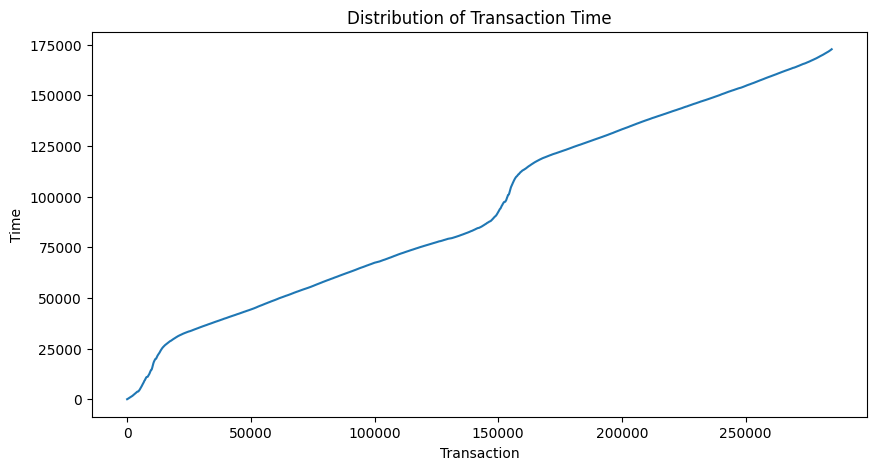

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df["Time"])
plt.xlabel("Transaction")
plt.ylabel("Time")
plt.title("Distribution of Transaction Time")
plt.show()

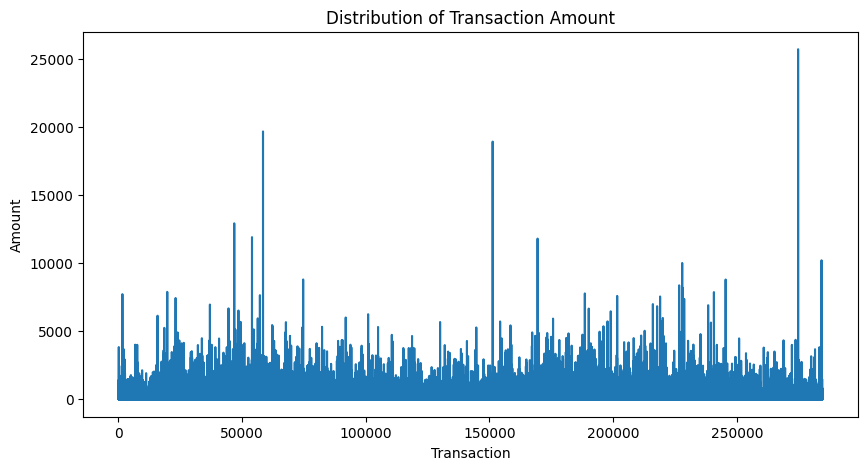

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df["Amount"])
plt.xlabel("Transaction")
plt.ylabel("Amount")
plt.title("Distribution of Transaction Amount")
plt.show()

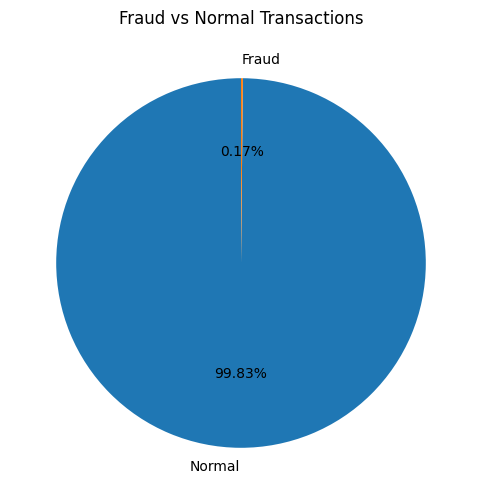

In [15]:
plt.figure(figsize=(6,6))

df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=['Normal','Fraud'],
    startangle=90
)

plt.title("Fraud vs Normal Transactions")
plt.ylabel("")
plt.show()

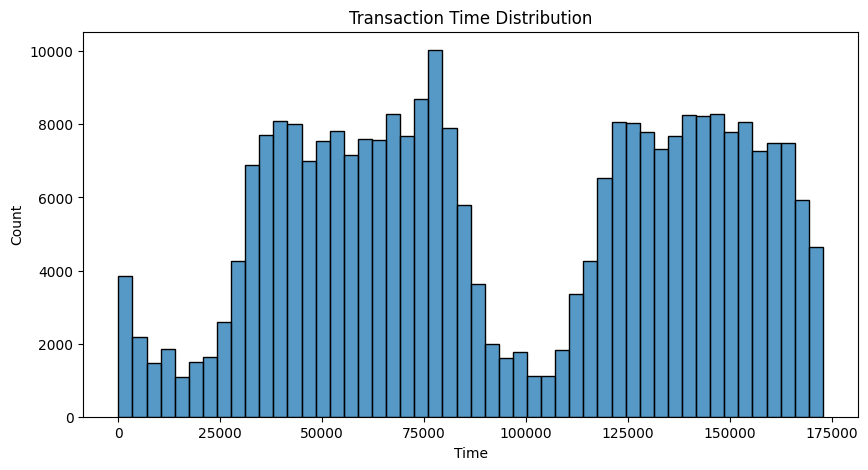

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")
plt.show()

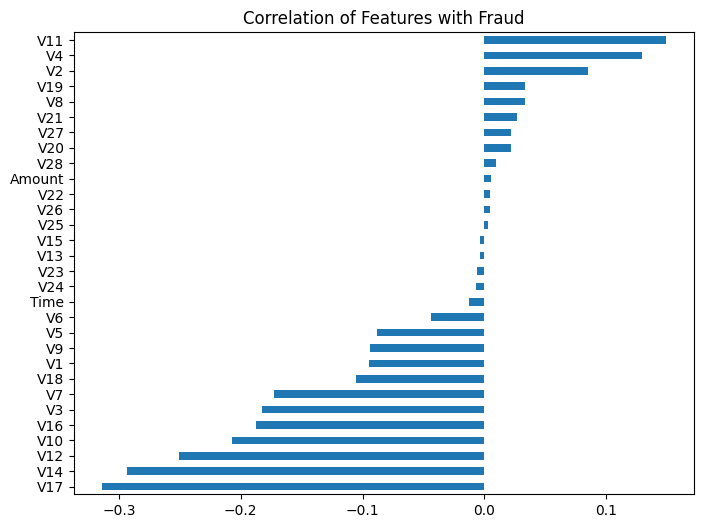

In [17]:
corr = df.corr()['Class'].sort_values()

plt.figure(figsize=(8,6))

corr.drop('Class').plot(kind='barh')

plt.title("Correlation of Features with Fraud")
plt.show()

# Data spliting

In [18]:
x = df.drop('Class', axis=1)
y = df['Class']

# Performing Train_Test Split

In [19]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

# performing standard scaling

In [20]:
scaler = StandardScaler()
xtrain[['Amount', 'Time']] = scaler.fit_transform(xtrain[['Amount', 'Time']])

xtest[['Amount', 'Time']] = scaler.transform(xtest[['Amount', 'Time']])

# Model Train and Evaluation

Logistic Regression

Training Score:  99.92025729139131 %
Test Score:  99.91541254009093 %
Accuracy Score:  99.91541254009093 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.88      0.54      0.67        90

    accuracy                           1.00     56746
   macro avg       0.94      0.77      0.84     56746
weighted avg       1.00      1.00      1.00     56746



<Axes: >

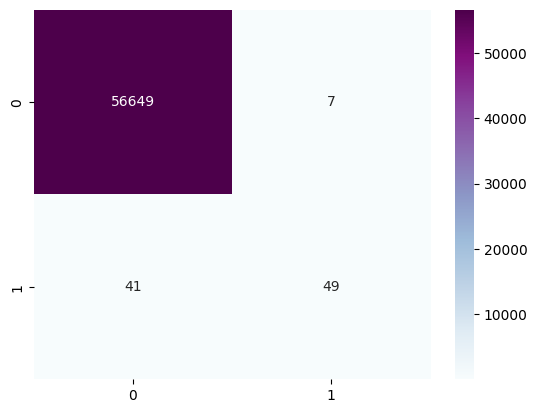

In [21]:
lr = LogisticRegression()
model_lr = lr.fit(xtrain, ytrain)
print("Training Score: ", model_lr.score(xtrain, ytrain)*100, "%")

print("Test Score: ", model_lr.score(xtest, ytest)*100, "%")

pred_lr = model_lr.predict(xtest)


#accuracy score
ac = accuracy_score(ytest, pred_lr)
print("Accuracy Score: ", ac*100, "%")

# classification report
cl_report = classification_report(ytest, pred_lr)
print("Classification Report:\n", cl_report)

#confusin matrix
cm = confusion_matrix(ytest, pred_lr)   

sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu')

# Random Forest

Training Score:  100.0 %
Test Score:  99.9066013463504 %
Accuracy Score:  99.9066013463504 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.69      0.73      0.71        90

    accuracy                           1.00     56746
   macro avg       0.85      0.87      0.86     56746
weighted avg       1.00      1.00      1.00     56746



<Axes: >

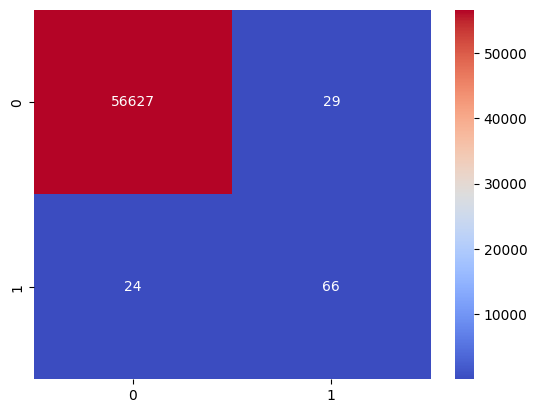

In [22]:
rf = DecisionTreeClassifier()
model_rf = rf.fit(xtrain, ytrain)
print("Training Score: ", model_rf.score(xtrain, ytrain)*100, "%")

print("Test Score: ", model_rf.score(xtest, ytest)*100, "%")

pred_rf = model_rf.predict(xtest)


#accuracy score
ac = accuracy_score(ytest, pred_rf)
print("Accuracy Score: ", ac*100, "%")

# classification report
cl_report = classification_report(ytest, pred_rf)
print("Classification Report:\n", cl_report)

#confusin matrix
cm = confusion_matrix(ytest, pred_rf)   

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')

# Decision Tree

Training Score:  100.0 %
Test Score:  99.9048391076023 %
Accuracy Score:  99.9048391076023 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.68      0.74      0.71        90

    accuracy                           1.00     56746
   macro avg       0.84      0.87      0.86     56746
weighted avg       1.00      1.00      1.00     56746



<Axes: >

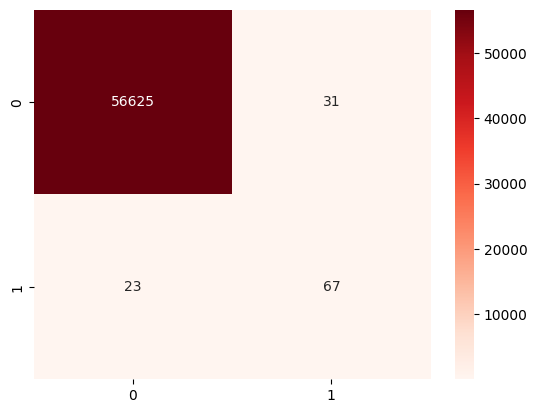

In [23]:
dt = DecisionTreeClassifier()
model_dt = dt.fit(xtrain, ytrain)
print("Training Score: ", model_dt.score(xtrain, ytrain)*100, "%")

print("Test Score: ", model_dt.score(xtest, ytest)*100, "%")

pred_dt = model_dt.predict(xtest)


#accuracy score
ac = accuracy_score(ytest, pred_dt)
print("Accuracy Score: ", ac*100, "%")

# classification report
cl_report = classification_report(ytest, pred_dt)
print("Classification Report:\n", cl_report)

#confusin matrix
cm = confusion_matrix(ytest, pred_dt)   

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

SVM

Training Score:  99.96519517138074 %
Test Score:  99.94360836006062 %
Accuracy Score:  99.94360836006062 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.98      0.66      0.79        90

    accuracy                           1.00     56746
   macro avg       0.99      0.83      0.89     56746
weighted avg       1.00      1.00      1.00     56746



<Axes: >

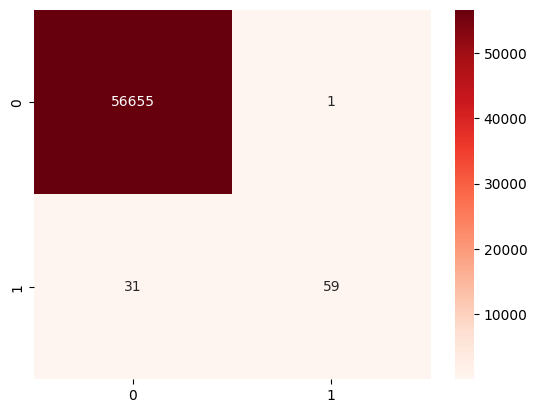

In [24]:
svm = SVC()
model_svm = svm.fit(xtrain, ytrain)
print("Training Score: ", model_svm.score(xtrain, ytrain)*100, "%")

print("Test Score: ", model_svm.score(xtest, ytest)*100, "%")

pred_svm = model_svm.predict(xtest)


#accuracy score
ac = accuracy_score(ytest, pred_svm)
print("Accuracy Score: ", ac*100, "%")

# classification report
cl_report = classification_report(ytest, pred_svm)
print("Classification Report:\n", cl_report)

#confusin matrix
cm = confusion_matrix(ytest, pred_svm)   

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

# Peak Best Model

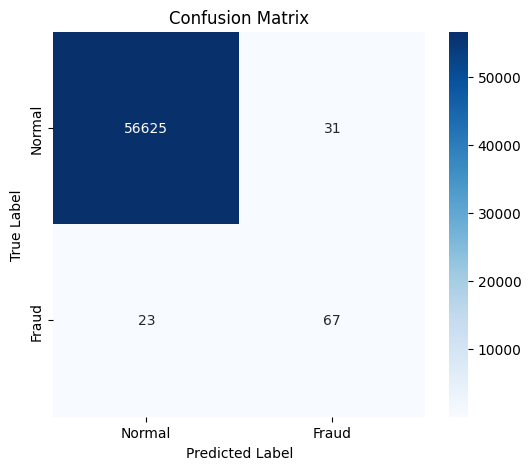

In [25]:

cm = confusion_matrix(ytest, pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Fraud"],
    yticklabels=["Normal","Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Choose the Best model

In [26]:
best_model = model_dt

# Top 15 Feature Importance

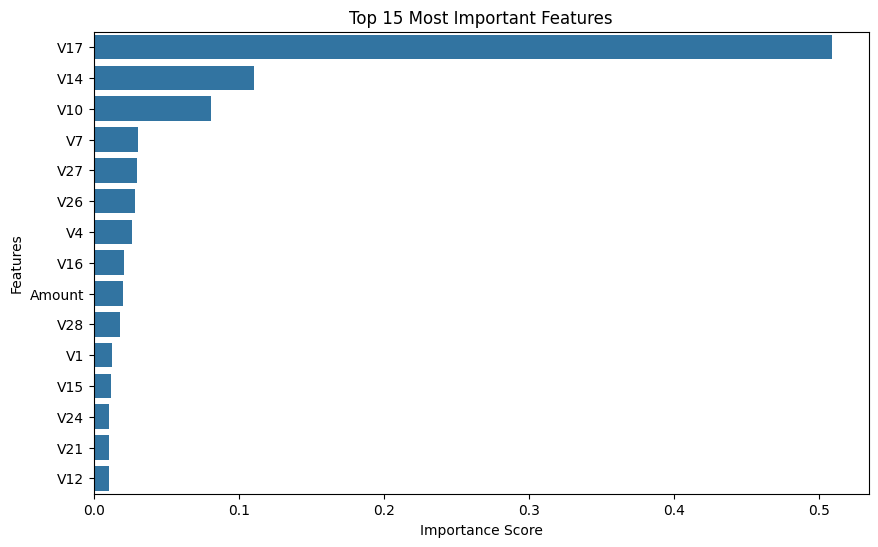

In [27]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": xtrain.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Save best model


In [28]:

with open("fraud_detection_model.pkl", "wb") as file:
    pickle.dump(best_model, file)